First 5 rows:
        Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0    6

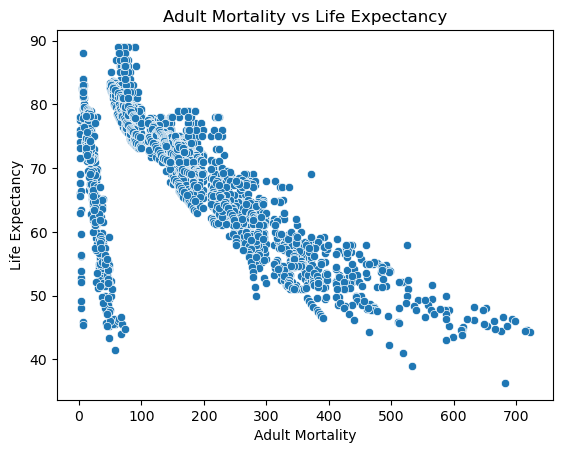

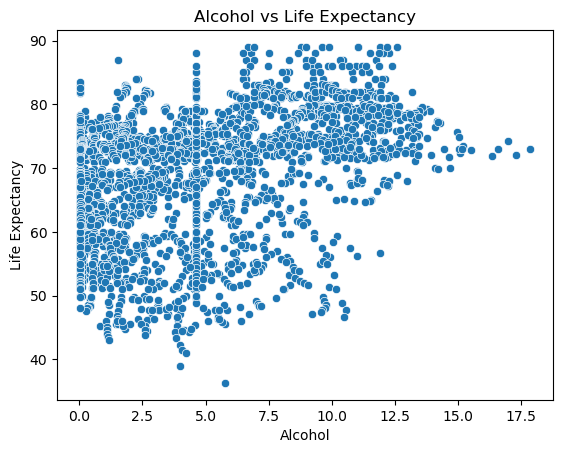

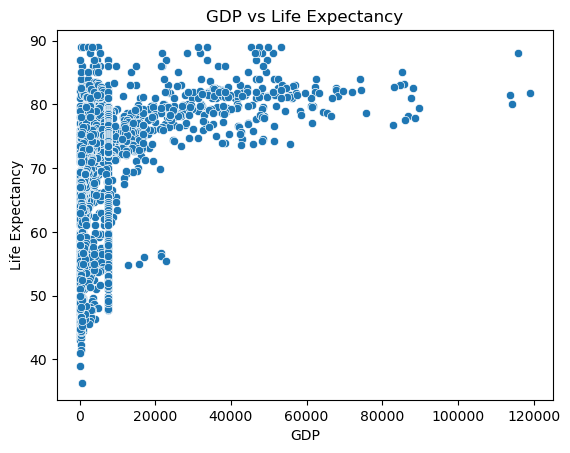

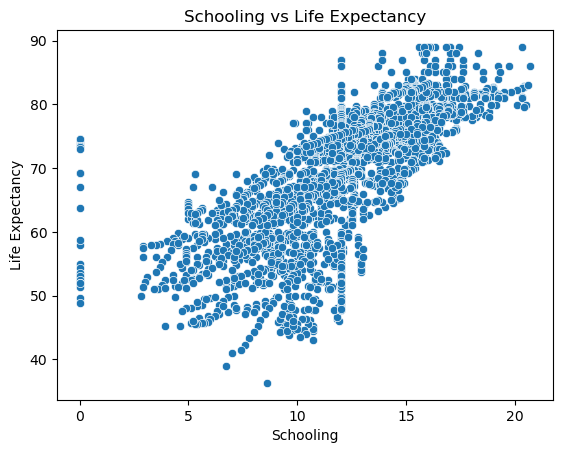

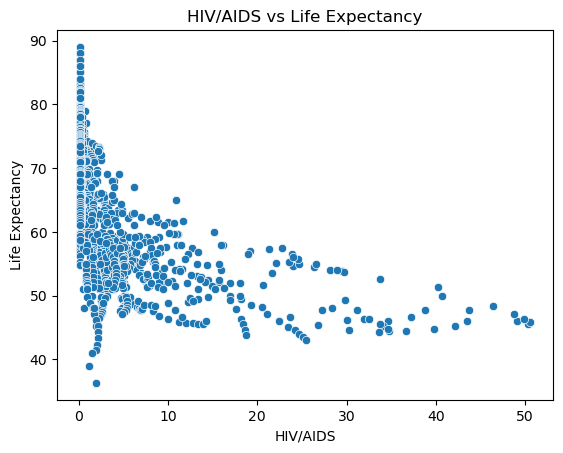

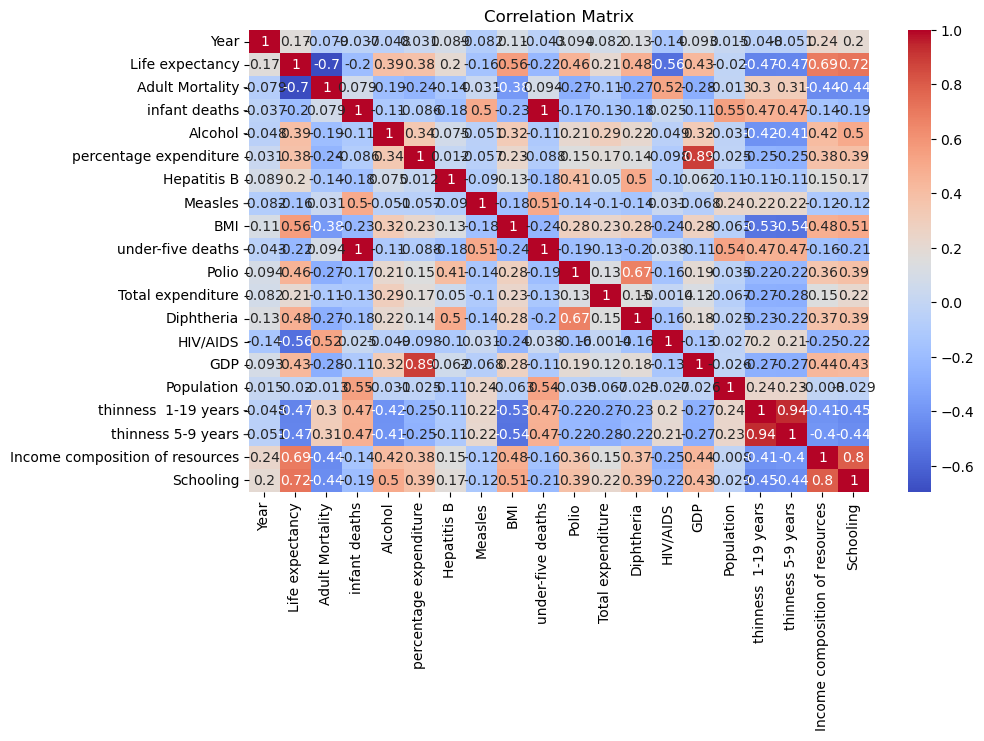


Model Evaluation:
Mean Squared Error (MSE): 20.73538173323825
R² Score: 0.7606589085483251

Feature Coefficients:
            Feature  Coefficient
0  Adult Mortality    -0.025286
1          Alcohol     0.163961
2              GDP     0.000066
3        Schooling     1.277675
4         HIV/AIDS    -0.502265

Intercept: 57.762975194050085


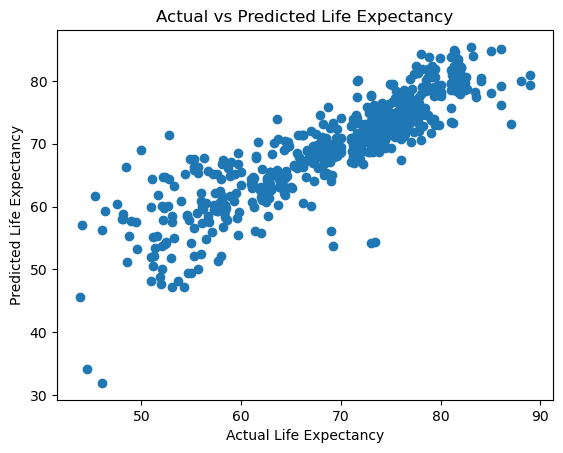

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("Life Expectancy Data.csv")  
df.columns = df.columns.str.strip()
print("First 5 rows:\n", df.head())
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())

print("\nStatistical Summary:\n", df.describe())

df.fillna(df.mean(numeric_only=True), inplace=True)


features = ["Adult Mortality", "Alcohol", "GDP", "Schooling", "HIV/AIDS"]

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df["Life expectancy"])
    plt.title(f"{col} vs Life Expectancy")
    plt.xlabel(col)
    plt.ylabel("Life Expectancy")
    plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



X = df[["Adult Mortality", "Alcohol", "GDP", "Schooling", "HIV/AIDS"]]
y = df["Life expectancy"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:\n", coefficients)

print("\nIntercept:", model.intercept_)


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()




